In [41]:
#installing hugging face's nlp package
#import all the libraries
!pip install nlp

In [42]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import nlp
import random
def show_history(h):
  epochs_trained = len(h.history['loss'])
  plt.figure(figsize=(16,6))

  plt.subplot(1,2,1)
  plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
  plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
  plt.ylim([0., 1.])
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
  plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()

print('using tensorlow version', tf.__version__)

using tensorlow version 2.19.0


In [43]:
!rm -rf /root/.cache/huggingface
!rm -rf /root/.cache/datasets


In [44]:
!pip install -U datasets


In [45]:
from datasets import load_dataset

dataset = load_dataset("emotion")


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [46]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [47]:
train = dataset['train']
val = dataset['validation']
test = dataset['test']

In [48]:
def get_tweet(data):
  tweets = [x['text'] for x in data]
  labels = [x['label']for x in data]
  return tweets, labels

In [49]:
tweets , labels = get_tweet(train)

In [50]:
tweets[0], labels[0]

('i didnt feel humiliated', 0)

In [51]:
dataset["train"].features["label"]


ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

In [52]:
tweets[1], labels[1]

('i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 0)

In [53]:
#Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer


In [54]:
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')
tokenizer.fit_on_texts(tweets)
tokenizer.texts_to_sequences([tweets[0]])

[[2, 139, 3, 679]]

In [55]:
tweets[0]

'i didnt feel humiliated'

In [56]:
import matplotlib.pyplot as plt


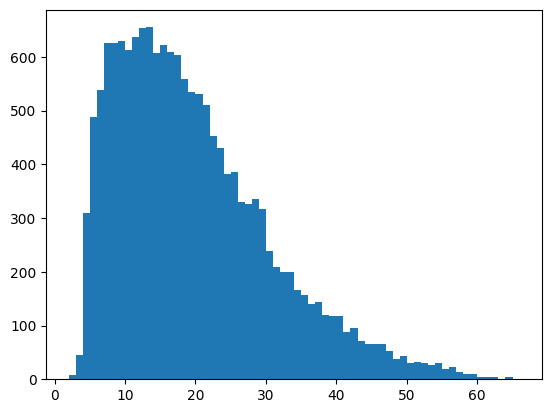

In [57]:
#padding and truncated sequences
lengths = [len(t.split(' ')) for t in tweets]
plt.hist(lengths, bins = len(set(lengths)))
plt.show()

In [58]:
maxlen = 50
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [59]:
def get_sequences(tokenizer,tweets):
  sequences = tokenizer.texts_to_sequences(tweets)
  padded = pad_sequences(sequences, truncating='post', padding='post', maxlen=maxlen)
  return padded

In [60]:
padded_train_seq = get_sequences(tokenizer,tweets)

In [61]:
padded_train_seq[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

In [62]:
#preparing the labels
classes = set(labels)
print(classes)

{0, 1, 2, 3, 4, 5}


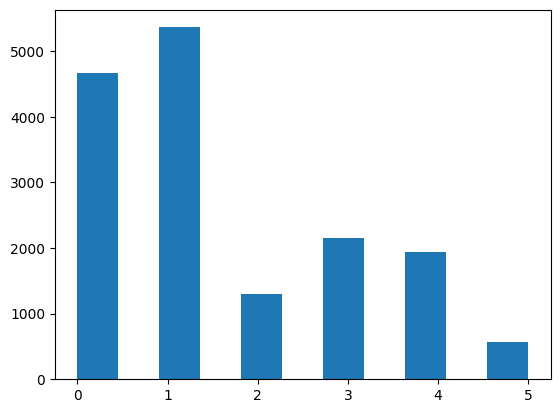

In [63]:
plt.hist(labels, bins=11)
plt.show()

In [64]:
class_to_index = dict((c,i) for i,c in enumerate(classes))
index_to_class = dict((v,k) for v,k in class_to_index.items())

In [65]:
class_to_index

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

In [66]:
index_to_class

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}

In [67]:
names_to_ids = lambda labels: np.array([class_to_index.get(x) for x in labels])

In [68]:
dataset["train"].features["label"].names  #optional


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [69]:
import numpy as np
train_labels = names_to_ids(labels)
print(train_labels[0])

0


In [70]:
#creating the model
import tensorflow as tf
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16, input_length=maxlen),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(20, return_sequences=True)
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(20)
    ),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [71]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
#training the model
val_tweets, val_labels = get_tweet(val)
val_seq = get_sequences(tokenizer, val_tweets)
val_labels = names_to_ids(val_labels)

In [73]:
val_tweets[0], val_labels[0]

('im feeling quite sad and sorry for myself but ill snap out of it soon',
 np.int64(0))

In [74]:
h = model.fit(
    padded_train_seq, train_labels,
    validation_data = (val_seq, val_labels),
    epochs = 20,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)
    ]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.3869 - loss: 1.5362 - val_accuracy: 0.6175 - val_loss: 1.0017
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.6881 - loss: 0.8422 - val_accuracy: 0.7465 - val_loss: 0.7026
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.8165 - loss: 0.5385 - val_accuracy: 0.8160 - val_loss: 0.5812
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.8772 - loss: 0.3700 - val_accuracy: 0.8330 - val_loss: 0.5184
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.9185 - loss: 0.2491 - val_accuracy: 0.8610 - val_loss: 0.4712
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.9421 - loss: 0.1765 - val_accuracy: 0.8700 - val_loss: 0.4402
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9608 - loss: 0.1244 - val_accuracy: 0.8715 - val_loss: 0.4361
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.9692 - loss: 0.0984 - 

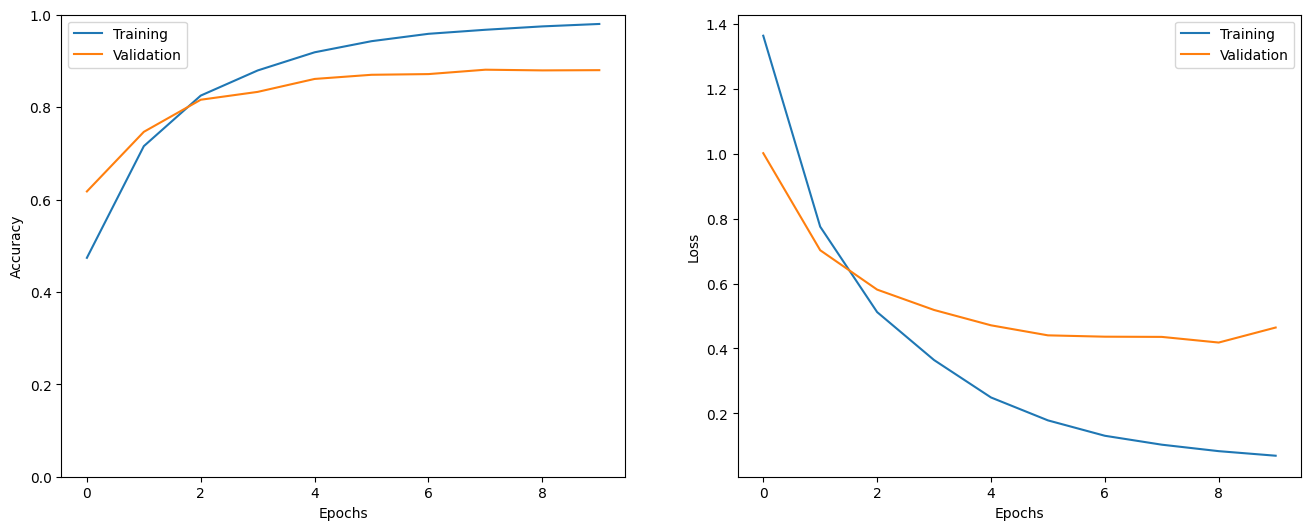

In [75]:
#evaluating the model
show_history(h)

In [76]:
test_tweets, test_labels = get_tweet(test)
test_seq = get_sequences(tokenizer, test_tweets)
test_labels = names_to_ids(test_labels)

In [77]:
_ = model.evaluate(test_seq, test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8834 - loss: 0.4330


In [100]:
import random
import numpy as np

# label index → class name
index_to_class = dataset["train"].features["label"].names

# pick random test example
i = random.randint(0, len(test_labels) - 1)

print('Sentence:', test_tweets[i])
print('Actual Emotion:', index_to_class[test_labels[i]])

# prediction
p = model.predict(np.expand_dims(test_seq[i], axis=0))[0]
pred_class = index_to_class[np.argmax(p)]

print('Predicted Emotion:', pred_class)


Sentence: ill let myself shed a few tears and feel bitter confused frustrated and hurt for the last time
Actual Emotion: anger
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Emotion: anger


In [101]:
import numpy as np

preds = model.predict(test_seq)
pred_labels = np.argmax(preds, axis=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [102]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def show_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, cmap='Blues')
    plt.xticks(range(len(classes)), classes, rotation=45)
    plt.yticks(range(len(classes)), classes)
    plt.colorbar()
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()


In [103]:
class_names = dataset["train"].features["label"].names


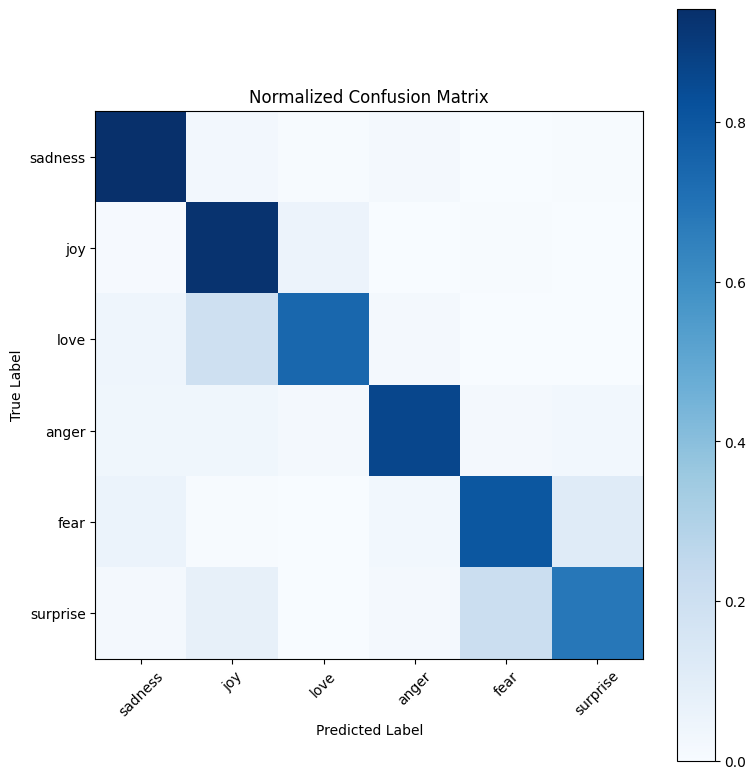

In [104]:
show_confusion_matrix(test_labels, pred_labels, class_names)
